In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score
import shap
import xgboost as xgb

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\user\Desktop\DATA WEB\Medical_Device_Failure_dataset.csv")

print(f"Dataset loaded successfully. Shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded successfully. Shape: (4149, 13)
Columns: ['Device_ID', 'Device_Type', 'Purchase_Date', 'Age', 'Manufacturer', 'Model', 'Country', 'Maintenance_Cost', 'Downtime', 'Maintenance_Frequency', 'Failure_Event_Count', 'Maintenance_Class', 'Maintenance_Report']


,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report
0,MD03449,Defibrillator,23/04/2018,7,CardioSync,Model-100,France,7115.349585,7.933824,3,0,1,Component component upgrade after detecting ov...
1,MD02024,Infusion Pump,10/12/2020,5,MedEquip,Model-650,Italy,7290.780658,7.838711,3,4,2,battery wear caused operational delay; replace...
2,MD04239,MRI Scanner,22/11/2023,2,ImagingTech,Model-650,France,5635.521788,13.911045,1,2,3,data lag caused operational delay; component u...
3,MD00153,Defibrillator,03/03/2021,4,RescueTech,Model-450,UK,5001.360188,29.059510,3,1,3,Routine check completed; battery wear observed...
4,MD03743,Defibrillator,16/05/2019,6,RescueTech,Model-450,Canada,7555.132928,13.942355,4,4,2,Component inspection after detecting voltage s...


In [3]:
# Convert date and calculate age
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format='%d/%m/%Y', errors='coerce')
current_year = datetime.now().year
df['Age_Years'] = current_year - df['Purchase_Date'].dt.year

# Clean cost column
df['Maintenance_Cost'] = df['Maintenance_Cost'].abs()

# Fill missing values
df['Downtime'] = df['Downtime'].fillna(df['Downtime'].median())
df['Maintenance_Cost'] = df['Maintenance_Cost'].fillna(df['Maintenance_Cost'].median())

# Derived features
df['Cost_per_Downtime'] = df['Maintenance_Cost'] / (df['Downtime'] + 1e-5)
df['Failure_Rate'] = df['Failure_Event_Count'] / (df['Age_Years'] + 1)
df['High_Maintenance_Flag'] = (df['Maintenance_Frequency'] > df['Maintenance_Frequency'].quantile(0.75)).astype(int)

print("Structured feature engineering completed.")
print(f"Current shape: {df.shape}")

Structured feature engineering completed.
Current shape: (4149, 17)


In [4]:
# Advanced NLP Feature Extraction.
def extract_failure_features(text):
    if not isinstance(text, str) or pd.isna(text):
        return {}
    text_lower = text.lower()
    features = {
        'overheating': len(re.findall(r'overheat|overheating', text_lower)),
        'voltage_spike': len(re.findall(r'voltage.?spike', text_lower)),
        'battery_wear': len(re.findall(r'battery.?wear', text_lower)),
        'software_crash': len(re.findall(r'software.?crash|system.?crash', text_lower)),
        'sensor_misalignment': len(re.findall(r'sensor.?misalign|misalignment', text_lower)),
        'data_lag': len(re.findall(r'data.?lag|data.?loss', text_lower)),
        'circuit_failure': len(re.findall(r'circuit.?failure', text_lower)),
        'abnormal_sound': len(re.findall(r'abnormal.?sound', text_lower)),
        'critical': len(re.findall(r'critical|emergency|urgent|high.?priority', text_lower)),
        'replacement': len(re.findall(r'replacement|replaced', text_lower)),
        'firmware_update': len(re.findall(r'firmware.?update|driver.?update', text_lower)),
    }
    features['report_length'] = len(text_lower.split())
    return features

nlp_features = df['Maintenance_Report'].apply(extract_failure_features)
nlp_df = pd.json_normalize(nlp_features).add_prefix('nlp_')

df = pd.concat([df.reset_index(drop=True), nlp_df.reset_index(drop=True)], axis=1)

print("NLP features extracted successfully.")
print(f"Final dataframe shape: {df.shape}")

NLP features extracted successfully.
Final dataframe shape: (4149, 29)


In [5]:
# Binary target: High failure risk
df['high_risk'] = (df['Failure_Event_Count'] >= 3).astype(int)

print("Target distribution:")
print(df['high_risk'].value_counts(normalize=True))

# Select features
structured_cols = ['Age_Years', 'Maintenance_Cost', 'Downtime', 'Maintenance_Frequency',
                   'Failure_Rate', 'Cost_per_Downtime', 'High_Maintenance_Flag']

nlp_cols = [col for col in df.columns if col.startswith('nlp_')]

feature_cols = structured_cols + nlp_cols
X = df[feature_cols].fillna(0)
y = df['high_risk']

print(f"Final feature matrix shape: {X.shape}")

Target distribution:
high_risk
0    0.69583
1    0.30417
Name: proportion, dtype: float64
Final feature matrix shape: (4149, 19)


In [6]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaling completed.")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Data split and scaling completed.
Train shape: (3111, 19), Test shape: (1038, 19)


In [7]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Model Performance:")
print(classification_report(y_test, y_pred, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

XGBoost Model Performance:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       722
           1     1.0000    1.0000    1.0000       316

    accuracy                         1.0000      1038
   macro avg     1.0000    1.0000    1.0000      1038
weighted avg     1.0000    1.0000    1.0000      1038

ROC-AUC: 1.0000
Average Precision: 1.0000


Generating SHAP summary plot...


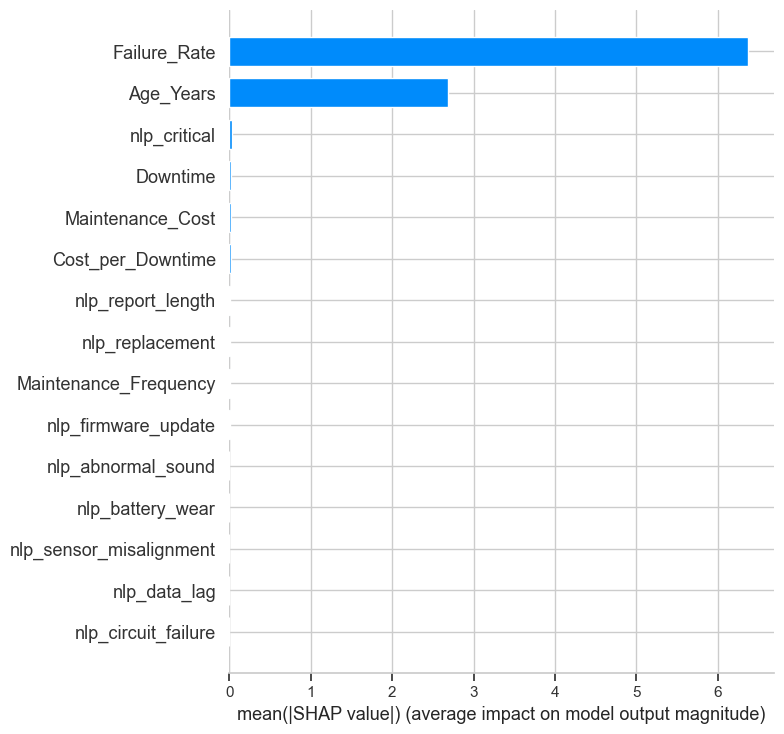


Top 10 Most Important Features:
                  feature  importance
4            Failure_Rate    6.370214
0               Age_Years    2.688371
15           nlp_critical    0.034433
2                Downtime    0.027290
1        Maintenance_Cost    0.025781
5       Cost_per_Downtime    0.022623
18      nlp_report_length    0.010566
16        nlp_replacement    0.010346
3   Maintenance_Frequency    0.010202
17    nlp_firmware_update    0.006112


In [8]:
# SHAP analysis for interpretability
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)

# Top 10 most important features
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(shap_importance.head(10))

In [9]:
# Neural Network Model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

class MultiModalNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

model = MultiModalNet(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

for epoch in range(60):
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/60 completed")

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_probs = test_outputs.squeeze().numpy()
    test_preds = (test_probs > 0.5).astype(int)

print("\nNeural Network Performance:")
print(classification_report(y_test, test_preds, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")

Epoch 20/60 completed
Epoch 40/60 completed
Epoch 60/60 completed

Neural Network Performance:
              precision    recall  f1-score   support

           0     1.0000    0.9931    0.9965       722
           1     0.9844    1.0000    0.9922       316

    accuracy                         0.9952      1038
   macro avg     0.9922    0.9965    0.9943      1038
weighted avg     0.9953    0.9952    0.9952      1038

ROC-AUC: 1.0000


In [10]:
# Final comparison
print("Multi-Modal Predictive Maintenance Framework Results")
print(f"XGBoost ROC-AUC     : {roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:,1]):.4f}")
print(f"Neural Network ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")

# Save models and results
import joblib
joblib.dump(xgb_model, 'xgb_predictive_maintenance_model.pkl')
torch.save(model.state_dict(), 'nn_predictive_maintenance_model.pth')

df.to_csv('processed_medical_device_data.csv', index=False)

print("\nModels and processed data saved successfully.")
print("This framework is ready for deployment in predictive maintenance pipelines.")

Multi-Modal Predictive Maintenance Framework Results
XGBoost ROC-AUC     : 1.0000
Neural Network ROC-AUC: 1.0000

Models and processed data saved successfully.
This framework is ready for deployment in predictive maintenance pipelines.


In [12]:
# Hyperparameter tunning with Optuna.
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning with GridSearchCV...")

# Defining parameter grid for XGBoost
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Base model
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='auc', use_label_encoder=False)

# Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest hyperparameters found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Train final tuned model with best parameters
xgb_tuned = grid_search.best_estimator_
xgb_tuned.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred_tuned = xgb_tuned.predict(X_test_scaled)
y_prob_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

print("\nTuned XGBoost Performance on Test Set:")
print(classification_report(y_test, y_pred_tuned, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_tuned):.4f}")

Starting Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best hyperparameters found:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best Cross-Validation ROC-AUC: 1.0000

Tuned XGBoost Performance on Test Set:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       722
           1     1.0000    1.0000    1.0000       316

    accuracy                         1.0000      1038
   macro avg     1.0000    1.0000    1.0000      1038
weighted avg     1.0000    1.0000    1.0000      1038

ROC-AUC Score: 1.0000
Average Precision: 1.0000


In [13]:
from sklearn.model_selection import StratifiedKFold

print("Performing 5-Fold Stratified Cross-Validation on Tuned Model...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_ap_scores = []

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_cv = xgb.XGBClassifier(**grid_search.best_params_, 
                                 random_state=42, eval_metric='auc', use_label_encoder=False)
    model_cv.fit(X_tr, y_tr)
    
    pred_prob = model_cv.predict_proba(X_val)[:, 1]
    cv_scores.append(roc_auc_score(y_val, pred_prob))
    cv_ap_scores.append(average_precision_score(y_val, pred_prob))

print(f"\nCross-Validation Results:")
print(f"Mean ROC-AUC     : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"Mean Avg Precision: {np.mean(cv_ap_scores):.4f} ± {np.std(cv_ap_scores):.4f}")

Performing 5-Fold Stratified Cross-Validation on Tuned Model...

Cross-Validation Results:
Mean ROC-AUC     : 1.0000 ± 0.0000
Mean Avg Precision: 1.0000 ± 0.0000
